In [65]:
import pandas as pd   #importing Pandas Library
import seaborn as sns  # importing Seaborn library
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split    # for spliting the train and test data
from sklearn.preprocessing import StandardScaler        # for scalling variablen into one unit
from sklearn.linear_model import LinearRegression       #Regresssion (for pridiction)
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df= pd.read_csv(r'D:\datasets\cardekho_dataset.csv')  # Data Loading--
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [3]:
# Data Information Gathering----
df.shape

(15411, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [5]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [8]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
15406    False
15407    False
15408    False
15409    False
15410    False
Length: 15411, dtype: bool

In [9]:
df.isnull().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [10]:
df.drop(columns= "Unnamed: 0" , inplace = True)

In [32]:
df.drop(columns=['car_name','model'], inplace=True)

In [33]:
df

,brand,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


(array([1.5192e+04, 1.9700e+02, 1.8000e+01, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([   40000.,  3986000.,  7932000., 11878000., 15824000., 19770000.,
        23716000., 27662000., 31608000., 35554000., 39500000.]),
 <BarContainer object of 10 artists>)

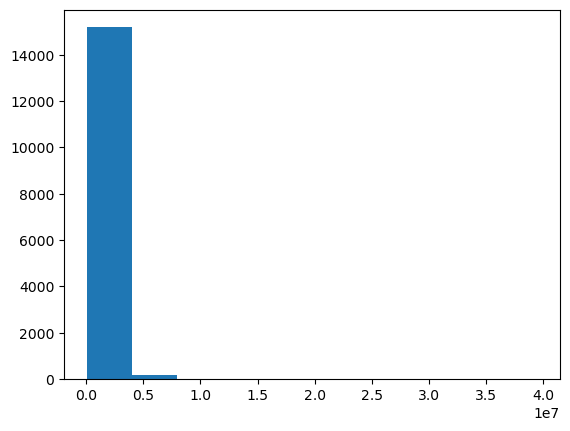

In [15]:
# Data Visualisation----
plt.hist(df['selling_price'], bins=10)

<Axes: xlabel='count', ylabel='brand'>

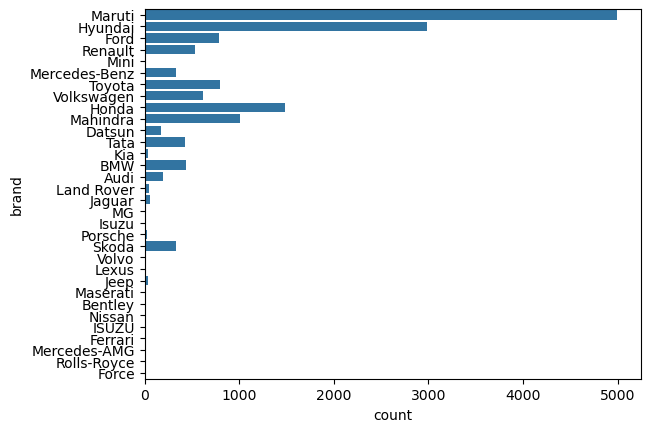

In [25]:
sns.countplot( y="brand" ,data= df)

<Axes: xlabel='km_driven', ylabel='selling_price'>

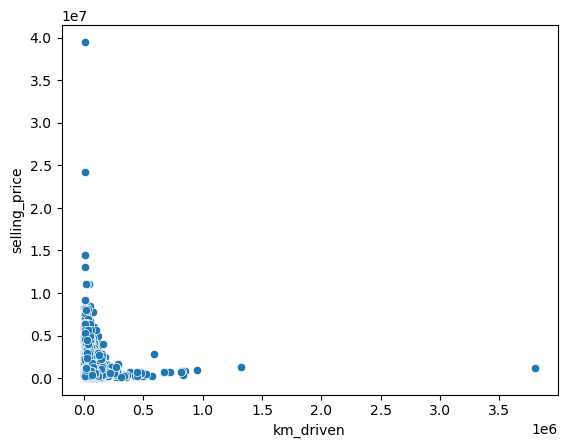

In [26]:
sns.scatterplot(x='km_driven',y='selling_price', data= df)

<Axes: ylabel='selling_price'>

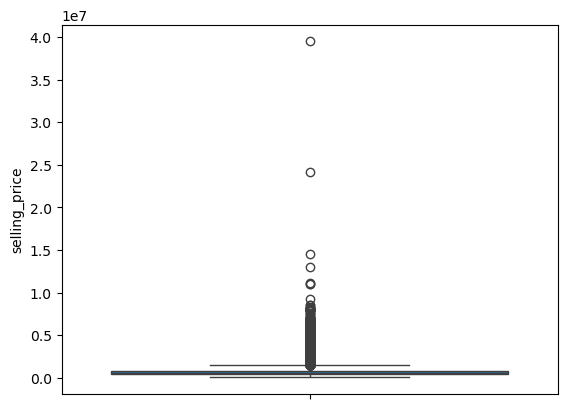

In [28]:
sns.boxplot(y= 'selling_price' , data = df)

In [35]:
df['brand'].unique()

array(['Maruti', 'Hyundai', 'Ford', 'Renault', 'Mini', 'Mercedes-Benz',
       'Toyota', 'Volkswagen', 'Honda', 'Mahindra', 'Datsun', 'Tata',
       'Kia', 'BMW', 'Audi', 'Land Rover', 'Jaguar', 'MG', 'Isuzu',
       'Porsche', 'Skoda', 'Volvo', 'Lexus', 'Jeep', 'Maserati',
       'Bentley', 'Nissan', 'ISUZU', 'Ferrari', 'Mercedes-AMG',
       'Rolls-Royce', 'Force'], dtype=object)

In [42]:
df.drop(columns=['brand'], inplace=True)

In [43]:
df['seller_type'].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

In [37]:
df['fuel_type'].unique()


array(['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric'], dtype=object)

In [38]:
df['transmission_type'].unique()

array(['Manual', 'Automatic'], dtype=object)

In [44]:
df['seller_type'] = df['seller_type'].map({
    'Individual': 0,
    'Dealer': 1,
    'Trustmark Dealer': 2
})

In [45]:
df['fuel_type'] = df['fuel_type'].map({
    'Petrol': 0,
    'Diesel': 1,
    'CNG': 2,
    'LPG': 3
})

In [46]:
df['transmission_type'] = df['transmission_type'].map({
    'Manual': 0,
    'Automatic': 1
})

In [52]:
df.isnull().sum()

vehicle_age          0
km_driven            0
seller_type          0
fuel_type            4
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [53]:
df = df.dropna()

In [54]:
df.isnull().sum()

vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [55]:
X = df.drop('selling_price', axis=1)

In [56]:
y = df['selling_price']
import numpy as np

y = np.log1p(df['selling_price'])

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [60]:
y_pred = lr.predict(X_test)

print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : 0.8652239215135937


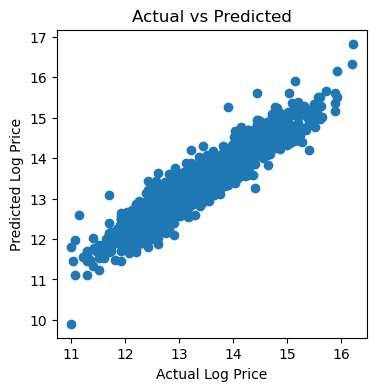

In [62]:
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")

plt.title("Actual vs Predicted")

plt.show()

In [63]:
y_test_original = np.expm1(y_test)

y_pred_original = np.expm1(y_pred)

In [64]:
comparison = pd.DataFrame({
    'Actual Price': y_test_original,
    'Predicted Price': y_pred_original
})

comparison.head(10)

,Actual Price,Predicted Price
2997,655000.0,710495.698584
6881,575000.0,691327.006109
6742,280000.0,238316.551616
3510,300000.0,285666.173456
764,435000.0,397971.903841
13945,470000.0,469627.158881
1768,550000.0,594413.288984
10634,520000.0,475013.612731
14256,895000.0,883484.108710
6587,485000.0,529510.816715


# Logistic Regression- 

In [68]:
df = df.copy()
df.loc[:, 'sell_quickly'] = df['selling_price'].apply(
    lambda x: 1 if x > median_price else 0
)

In [69]:
print(df['sell_quickly'].value_counts())

sell_quickly
0    7706
1    7701
Name: count, dtype: int64


In [70]:
X = df.drop(['selling_price', 'sell_quickly'], axis=1)
y = df['sell_quickly']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [74]:
y_pred = log_model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8598312783906554


In [76]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1324  216]
 [ 216 1326]]


In [77]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1540
           1       0.86      0.86      0.86      1542

    accuracy                           0.86      3082
   macro avg       0.86      0.86      0.86      3082
weighted avg       0.86      0.86      0.86      3082

